# 1. Import thư viện

In [1]:
print("[Thông báo] Đang import thư viện...")
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split, Dataset, DataLoader
from gensim.models import KeyedVectors
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid') # Giúp biểu đồ có lưới nhìn chuyên nghiệp hơn

# 1. Tải font Roboto về (nếu chưa có)
!wget -q -O Roboto-Regular.ttf https://github.com/googlefonts/roboto/raw/main/src/hinted/Roboto-Regular.ttf

# 2. Đọc đích danh file font và lấy tên gốc của nó
font_path = 'Roboto-Regular.ttf'
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name() # Trích xuất tên chuẩn của font

# 3. GHI ĐÈ cấu hình gốc của cả Matplotlib lẫn Seaborn
plt.rcParams['font.family'] = font_name
sns.set(font=font_name) # Ép Seaborn nhận diện
sns.set_theme(style="white", font=font_name) 

print(f"✅ Đã ép hệ thống dùng font: {font_name}")

print("[Thông báo] Đã thực hiện xong việc import thư viện.")

[Thông báo] Đang import thư viện...
✅ Đã ép hệ thống dùng font: Roboto
[Thông báo] Đã thực hiện xong việc import thư viện.


# 2. Xây dựng Dataset và khởi tạo DataLoader

In [11]:
# 1. Nạp lõi Vector FastText/CBOW
word_vectors = KeyedVectors.load("/kaggle/input/datasets/qucvinhchu/cbowfasttext-word2vec-100/fashion_fasttext_core.kv")
EMBEDDING_DIM = 100 # Số chiều Embedding tuỳ thuộc vào lúc huấn luyện mô hình

# Tạo từ điển map từ chữ sang số (Thêm <PAD> ở vị trí 0 và <UNK> ở vị trí 1)
word2idx = {"<PAD>": 0, "<UNK>": 1}
for word in word_vectors.key_to_index:
    word2idx[word] = len(word2idx)

# Tạo ma trận trọng số để nạp vào Pytorch
vocab_size = len(word2idx)
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
for word, idx in word2idx.items():
    if word in word_vectors:
        embedding_matrix[idx] = word_vectors[word]

embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32)

# 2. Xây dựng Custom Dataset
class FashionReviewDataset(Dataset):
    def __init__(self, xlsx_file, word2idx, max_len=70):
        self.df = pd.read_excel(xlsx_file)
        label_cols = ['Chất liệu', 'Kiểu dáng', 'Kích cỡ', 'Giá cả', 'Dịch vụ']
        self.df[label_cols] = self.df[label_cols].fillna(0)
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Chuyển chuỗi tokenized thành list các số (index)
        text = str(row['Tokenized_Review']).split()
        indices = [self.word2idx.get(w, self.word2idx["<UNK>"]) for w in text]

        # Padding hoặc Truncating (cắt bớt nếu quá dài, thêm 0 nếu quá ngắn)
        if len(indices) < self.max_len:
            indices += [self.word2idx["<PAD>"]] * (self.max_len - len(indices))
        else:
            indices = indices[:self.max_len]

        # Lấy nhãn của 5 khía cạnh
        labels = {
            "chat_lieu": row['Chất liệu'],
            "kieu_dang": row['Kiểu dáng'],
            "kich_co": row['Kích cỡ'],
            "gia_ca": row['Giá cả'],
            "dich_vu": row['Dịch vụ']
        }

        return torch.tensor(indices, dtype=torch.long), {k: torch.tensor(v, dtype=torch.long) for k, v in labels.items()}

DATASET_PATH = "/kaggle/input/datasets/qucvinhchu/fashionreviewslabeled-tokenized/Tokenized_Reviews.xlsx"

# Khởi tạo DataLoader
print("[Thông báo] Đang khởi tạo Dataset...")
dataset = FashionReviewDataset(DATASET_PATH, word2idx)

# 1. TÍNH TOÁN KÍCH THƯỚC (90% Train - 10% Val)
total_size = len(dataset)
train_size = int(0.9 * total_size)
val_size = total_size - train_size

# 2. CHIA TÁCH DATASET NGẪU NHIÊN
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(f"[Thông báo] Tổng số lượng mẫu: {total_size}")
print(f"[Thông báo] Đã chia tập Train: {train_size} mẫu")
print(f"[Thông báo] Đã chia tập Validation: {val_size} mẫu")

# 3. KHỞI TẠO 2 DATALOADER KHÁC NHAU
BATCH_SIZE = 32 # Đặt lại batch_size giống như bạn đang dùng

# Tập Train cần shuffle=True để xáo trộn dữ liệu, tránh học vẹt
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Tập Val KHÔNG CẦN shuffle, chỉ dùng để chấm điểm
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
print("[Thông báo] Đã thực hiện xong việc khởi tạo Dataset.")

[Thông báo] Đang khởi tạo Dataset...
[Thông báo] Tổng số lượng mẫu: 95145
[Thông báo] Đã chia tập Train: 85630 mẫu
[Thông báo] Đã chia tập Validation: 9515 mẫu
[Thông báo] Đã thực hiện xong việc khởi tạo Dataset.


# 3. Xây dựng mô hình Bi-LSTM tích hợp Self-Attention

In [12]:
# 1. ĐỊNH NGHĨA LỚP SELF-ATTENTION
class SelfAttention(nn.Module):
    def __init__(self, hidden_dim):
        super(SelfAttention, self).__init__()
        # Mạng nơ-ron nhỏ để chấm điểm tầm quan trọng của từng từ
        self.projection = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1, bias=False)
        )

    def forward(self, encoder_outputs):
        # encoder_outputs: Chứa ngữ cảnh của TOÀN BỘ các từ trong câu
        # Kích thước: (batch_size, seq_len, hidden_dim)
        
        # Bước 1: Tính điểm năng lượng (energy) cho từng từ
        energy = self.projection(encoder_outputs) 
        
        # Bước 2: Dùng Softmax để chuyển điểm số thành trọng số (tổng các từ = 100%)
        # Từ nào mang cảm xúc mạnh (đẹp, xấu, đắt) sẽ có % lớn
        weights = torch.softmax(energy, dim=1) 
        
        # Bước 3: Nhân trọng số với ngữ cảnh từng từ và cộng dồn lại (Weighted Sum)
        # Tạo ra 1 vector duy nhất đại diện cho cả câu, nhưng dồn sự tập trung vào từ khóa
        context = torch.bmm(weights.transpose(1, 2), encoder_outputs).squeeze(1)
        
        # Trả về vector câu và cả bộ trọng số (để sau này vẽ biểu đồ nếu cần)
        return context, weights.squeeze(2)

# 2. ĐỊNH NGHĨA MÔ HÌNH BI-LSTM + ATTENTION
class MultiTaskBiLSTMAttention(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim=128, num_classes=4):
        super(MultiTaskBiLSTMAttention, self).__init__()
        
        # 1. Lớp Nhúng
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=False, padding_idx=0
        )

        self.dropout = nn.Dropout(0.3)
        
        # 2. LÕI BI-LSTM
        self.bilstm = nn.LSTM(
            input_size=embedding_matrix.shape[1], 
            hidden_size=hidden_dim, 
            num_layers=1, 
            batch_first=True,
            bidirectional=True 
        )
        
        # 3. LỚP SELF-ATTENTION
        # Đầu vào của Attention là hidden_dim * 2 (Vì Bi-LSTM đọc 2 chiều xuôi + ngược)
        self.attn_chat_lieu = SelfAttention(hidden_dim * 2)
        self.attn_kieu_dang = SelfAttention(hidden_dim * 2)
        self.attn_kich_co = SelfAttention(hidden_dim * 2)
        self.attn_gia_ca = SelfAttention(hidden_dim * 2)
        self.attn_dich_vu = SelfAttention(hidden_dim * 2)

        self.layer_norm = nn.LayerNorm(hidden_dim * 2)
        
        # 4. Các lớp Phân loại đa nhiệm
        self.fc_chat_lieu = nn.Linear(hidden_dim * 2, num_classes)
        self.fc_kieu_dang = nn.Linear(hidden_dim * 2, num_classes)
        self.fc_kich_co = nn.Linear(hidden_dim * 2, num_classes)
        self.fc_gia_ca = nn.Linear(hidden_dim * 2, num_classes)
        self.fc_dich_vu = nn.Linear(hidden_dim * 2, num_classes)
        
    def forward(self, x):
        embeds = self.embedding(x) 
        
        # Truyền qua Bi-LSTM
        # LƯU Ý: Lần này ta lấy `lstm_out` (chứa output của tất cả các từ), thay vì lấy `hidden`
        lstm_out, _ = self.bilstm(embeds)
        
        # 1. Nhánh Chất liệu
        vec_chat_lieu, _ = self.attn_chat_lieu(lstm_out)
        vec_chat_lieu = self.layer_norm(vec_chat_lieu)
        vec_chat_lieu = self.dropout(vec_chat_lieu)
        out_chat_lieu = self.fc_chat_lieu(vec_chat_lieu)
        
        # 2. Nhánh Kiểu dáng
        vec_kieu_dang, _ = self.attn_kieu_dang(lstm_out)
        vec_kieu_dang = self.layer_norm(vec_kieu_dang)
        vec_kieu_dang = self.dropout(vec_kieu_dang)
        out_kieu_dang = self.fc_kieu_dang(vec_kieu_dang)
        
        # 3. Nhánh Kích cỡ
        vec_kich_co, _ = self.attn_kich_co(lstm_out)
        vec_kich_co = self.layer_norm(vec_kich_co)
        vec_kich_co = self.dropout(vec_kich_co)
        out_kich_co = self.fc_kich_co(vec_kich_co)
        
        # 4. Nhánh Giá cả
        vec_gia_ca, _ = self.attn_gia_ca(lstm_out)
        vec_gia_ca = self.layer_norm(vec_gia_ca)
        vec_gia_ca = self.dropout(vec_gia_ca)
        out_gia_ca = self.fc_gia_ca(vec_gia_ca)
        
        # 5. Nhánh Dịch vụ
        vec_dich_vu, _ = self.attn_dich_vu(lstm_out)
        vec_dich_vu = self.layer_norm(vec_dich_vu)
        vec_dich_vu = self.dropout(vec_dich_vu)
        out_dich_vu = self.fc_dich_vu(vec_dich_vu)
        
        # Trả về 5 đầu ra
        return out_chat_lieu, out_kieu_dang, out_kich_co, out_gia_ca, out_dich_vu

# 4. Huấn luyện mô hình Bi-LSTM tích hợp Self-Attention

In [13]:
# 1. Khởi tạo mô hình Đỉnh cao nhất
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_bilstm_attn = MultiTaskBiLSTMAttention(embedding_matrix, hidden_dim=128, num_classes=4).to(device)

FILE_PATH = "/kaggle/input/datasets/qucvinhchu/fashionreviewslabeled-tokenized/Tokenized_Reviews.xlsx"
df = pd.read_excel(FILE_PATH)
df[['Chất liệu', 'Kiểu dáng', 'Kích cỡ', 'Giá cả', 'Dịch vụ']] = df[['Chất liệu', 'Kiểu dáng', 'Kích cỡ', 'Giá cả', 'Dịch vụ']].fillna(0)

# Tính trọng số hàm Weighted Cross-entropy Loss
label_cols = ['Chất liệu', 'Kiểu dáng', 'Kích cỡ', 'Giá cả', 'Dịch vụ']
num_classes = 4
weights_dict = {}

print("[Thông báo] Đang tự động tính toán trọng số cân bằng lớp...")
for col in label_cols:
    # Đếm số lượng mẫu thực tế của từng nhãn (0, 1, 2, 3)
    class_counts = df[col].value_counts().sort_index().values
    total_samples = class_counts.sum()
    
    # Công thức cốt lõi: Inverse Class Frequency (Nghịch đảo tần suất)
    # Trọng số = Tổng số mẫu / (Số lượng lớp * Số mẫu của lớp đó)
    weights = total_samples / (num_classes * class_counts)
    
    # Chuyển đổi thành Tensor để đẩy vào GPU cho PyTorch hiểu
    weights_dict[col] = torch.tensor(weights, dtype=torch.float32).to(device)

# Khởi tạo 5 hàm Loss độc lập tự động nhận trọng số vừa tính
criterion_chat_lieu = nn.CrossEntropyLoss(weight=weights_dict['Chất liệu'])
criterion_kieu_dang = nn.CrossEntropyLoss(weight=weights_dict['Kiểu dáng'])
criterion_kich_co = nn.CrossEntropyLoss(weight=weights_dict['Kích cỡ'])
criterion_gia_ca = nn.CrossEntropyLoss(weight=weights_dict['Giá cả'])
criterion_dich_vu = nn.CrossEntropyLoss(weight=weights_dict['Dịch vụ'])

# 2. Khai báo Optimizer
optimizer = optim.AdamW(model_bilstm_attn.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

EPOCHS = 20

# 1. TẠO MỘT MẢNG ĐỂ LƯU LỊCH SỬ LOSS
history_train_loss = []
history_val_loss = []
best_val_loss = float('inf')

print("[Thông báo] Bắt đầu vòng lặp huấn luyện...")

for epoch in range(EPOCHS):
    # PHA 1: HUẤN LUYỆN (TRAIN PHASE)
    model_bilstm_attn.train() # Bật chế độ cập nhật trọng số
    total_train_loss = 0
    
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]', leave=True)
    
    for inputs, labels in progress_bar:
        inputs = inputs.to(device)
        labels = {k: v.to(device) for k, v in labels.items()}
        
        optimizer.zero_grad()
        preds = model_bilstm_attn(inputs)
        
        # Tính Loss
        loss_chat_lieu = criterion_chat_lieu(preds[0], labels["chat_lieu"])
        loss_kieu_dang = criterion_kieu_dang(preds[1], labels["kieu_dang"])
        loss_kich_co = criterion_kich_co(preds[2], labels["kich_co"])
        loss_gia_ca = criterion_gia_ca(preds[3], labels["gia_ca"])
        loss_dich_vu = criterion_dich_vu(preds[4], labels["dich_vu"])
        
        loss = loss_chat_lieu + loss_kieu_dang + loss_kich_co + loss_gia_ca + loss_dich_vu
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_bilstm_attn.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_train_loss += loss.item()
        progress_bar.set_postfix({'train_loss': f"{loss.item():.4f}"})
        
    avg_train_loss = total_train_loss / len(train_loader)
    history_train_loss.append(avg_train_loss)

    # PHA 2: ĐÁNH GIÁ (VALIDATION PHASE)
    model_bilstm_attn.eval() # BẮT BUỘC: Đóng băng Dropout và khóa cập nhật trọng số
    total_val_loss = 0
    
    # BẮT BUỘC: Không tính đạo hàm (no_grad) để tiết kiệm cực nhiều RAM và chạy nhanh hơn
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = {k: v.to(device) for k, v in labels.items()}
            
            preds = model_bilstm_attn(inputs)
            
            loss_chat_lieu = criterion_chat_lieu(preds[0], labels["chat_lieu"])
            loss_kieu_dang = criterion_kieu_dang(preds[1], labels["kieu_dang"])
            loss_kich_co = criterion_kich_co(preds[2], labels["kich_co"])
            loss_gia_ca = criterion_gia_ca(preds[3], labels["gia_ca"])
            loss_dich_vu = criterion_dich_vu(preds[4], labels["dich_vu"])
            
            loss = loss_chat_lieu + loss_kieu_dang + loss_kich_co + loss_gia_ca + loss_dich_vu
            total_val_loss += loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    history_val_loss.append(avg_val_loss)
    
    # IN KẾT QUẢ SO SÁNH GIỮA 2 TẬP
    print(f"👉 Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # PHA 3: CÁC BƯỚC TỐI ƯU HÓA CUỐI EPOCH
    # 1. Cập nhật Scheduler dựa trên điểm Val Loss
    scheduler.step(avg_val_loss)

    # In ra Learning Rate hiện tại để tiện theo dõi
    current_lr = optimizer.param_groups[0]['lr']
    print(f"   🔹 Tốc độ học (Learning Rate) hiện tại: {current_lr}")
    
    # 2. Cơ chế lưu Model tốt nhất (Checkpointing)
    if avg_val_loss < best_val_loss:
        print(f"   🌟 Val Loss giảm từ {best_val_loss:.4f} xuống {avg_val_loss:.4f}. Đang lưu mô hình mới...")
        best_val_loss = avg_val_loss
        # Chỉ lưu mô hình vào ổ cứng khi nó thực sự giỏi hơn các vòng lặp trước
        torch.save(model_bilstm_attn.state_dict(), "/kaggle/working/multitask_bilstm_attn_best.pth")

[Thông báo] Đang tự động tính toán trọng số cân bằng lớp...
[Thông báo] Bắt đầu vòng lặp huấn luyện...


Epoch 1/20 [Train]: 100%|██████████| 2676/2676 [00:37<00:00, 71.31it/s, train_loss=1.2539]


👉 Epoch 1/20 | Train Loss: 1.9060 | Val Loss: 1.5501
   🔹 Tốc độ học (Learning Rate) hiện tại: 0.001
   🌟 Val Loss giảm từ inf xuống 1.5501. Đang lưu mô hình mới...


Epoch 2/20 [Train]: 100%|██████████| 2676/2676 [00:37<00:00, 71.54it/s, train_loss=1.6684]


👉 Epoch 2/20 | Train Loss: 1.5421 | Val Loss: 1.4918
   🔹 Tốc độ học (Learning Rate) hiện tại: 0.001
   🌟 Val Loss giảm từ 1.5501 xuống 1.4918. Đang lưu mô hình mới...


...

👉 Epoch 18/20 | Train Loss: 0.4132 | Val Loss: 2.4100
   🔹 Tốc độ học (Learning Rate) hiện tại: 6.25e-05


Epoch 19/20 [Train]: 100%|██████████| 2676/2676 [00:37<00:00, 71.29it/s, train_loss=0.4011]


👉 Epoch 19/20 | Train Loss: 0.4021 | Val Loss: 2.4657
   🔹 Tốc độ học (Learning Rate) hiện tại: 3.125e-05


Epoch 20/20 [Train]: 100%|██████████| 2676/2676 [00:37<00:00, 70.50it/s, train_loss=0.5716]


👉 Epoch 20/20 | Train Loss: 0.3827 | Val Loss: 2.5151
   🔹 Tốc độ học (Learning Rate) hiện tại: 3.125e-05


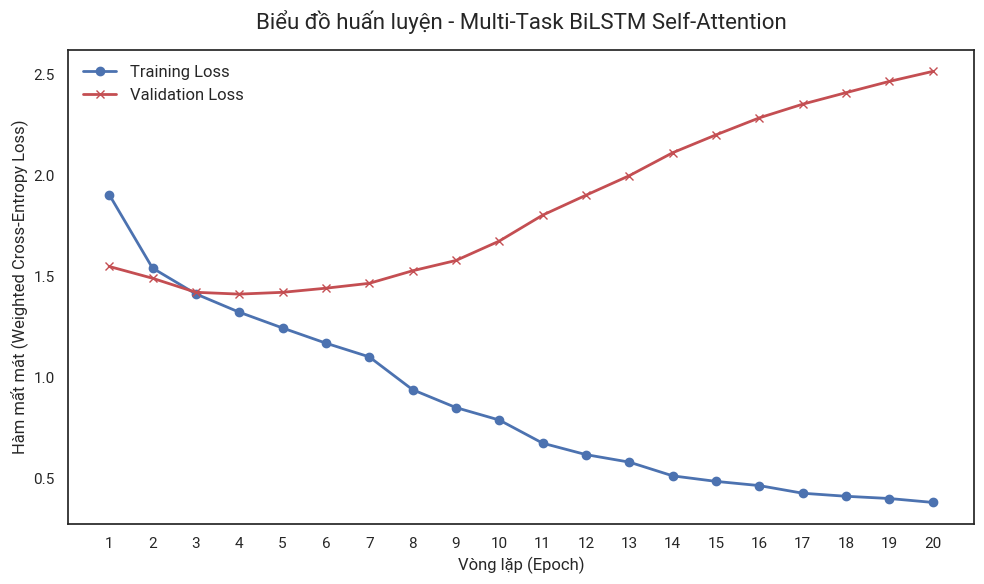

✅ Đã lưu biểu đồ vào file BiLSTM_Self-Attention_Training_Loss_Curve.png


<Figure size 640x480 with 0 Axes>

In [14]:
# Thiết lập kích thước và phong cách biểu đồ
plt.figure(figsize=(10, 6))

# Vẽ đường Loss
# Nối các điểm trong history_train_loss lại với nhau, đánh dấu bằng hình tròn (marker='o')
plt.plot(range(1, EPOCHS + 1), history_train_loss, marker='o', linestyle='-', color='b', linewidth=2, label='Training Loss')
plt.plot(range(1, EPOCHS + 1), history_val_loss, marker='x', linestyle='-', color='r', linewidth=2, label='Validation Loss')

# Trang trí biểu đồ
plt.title('Biểu đồ huấn luyện - Multi-Task BiLSTM Self-Attention', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Vòng lặp (Epoch)', fontsize=12)
plt.ylabel('Hàm mất mát (Weighted Cross-Entropy Loss)', fontsize=12)

# Ép trục X chỉ hiện số nguyên (1, 2, 3... 20) thay vì số thập phân (1.5, 2.5)
plt.xticks(range(1, EPOCHS + 1))

plt.legend(fontsize=12)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

# Lưu biểu đồ thành file ảnh để chèn vào báo cáo
plt.savefig("/kaggle/working/BiLSTM_Self-Attention_Training_Loss_Curve.png", dpi=300, bbox_inches='tight')
print("✅ Đã lưu biểu đồ vào file BiLSTM_Self-Attention_Training_Loss_Curve.png")

# 5. Đánh giá mô hình Bi-LSTM tích hợp Self-Attention

In [15]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# 1. Chuyển mô hình sang chế độ đánh giá
model_bilstm_attn.eval()

# 2. Khởi tạo dictionary để lưu trữ dự đoán và nhãn thực tế của 5 khía cạnh
all_preds = {"chat_lieu": [], "kieu_dang": [], "kich_co": [], "gia_ca": [], "dich_vu": []}
all_labels = {"chat_lieu": [], "kieu_dang": [], "kich_co": [], "gia_ca": [], "dich_vu": []}

print("[Thông báo] Đang chạy dữ liệu qua mô hình để đánh giá...")
with torch.no_grad(): # Tắt tính toán đạo hàm để tiết kiệm RAM và tăng tốc
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        
        # Nhận kết quả dự đoán (Dạng Logits: điểm số thô)
        preds = model_bilstm_attn(inputs)
        
        # Dùng argmax để biến điểm số thô thành nhãn có điểm cao nhất (0, 1, 2, 3)
        all_preds["chat_lieu"].extend(torch.argmax(preds[0], dim=1).cpu().numpy())
        all_preds["kieu_dang"].extend(torch.argmax(preds[1], dim=1).cpu().numpy())
        all_preds["kich_co"].extend(torch.argmax(preds[2], dim=1).cpu().numpy())
        all_preds["gia_ca"].extend(torch.argmax(preds[3], dim=1).cpu().numpy())
        all_preds["dich_vu"].extend(torch.argmax(preds[4], dim=1).cpu().numpy())
        
        # Lưu lại nhãn thực tế
        all_labels["chat_lieu"].extend(labels["chat_lieu"].numpy())
        all_labels["kieu_dang"].extend(labels["kieu_dang"].numpy())
        all_labels["kich_co"].extend(labels["kich_co"].numpy())
        all_labels["gia_ca"].extend(labels["gia_ca"].numpy())
        all_labels["dich_vu"].extend(labels["dich_vu"].numpy())

print("✅ Đã gom xong kết quả!")

[Thông báo] Đang chạy dữ liệu qua mô hình để đánh giá...
✅ Đã gom xong kết quả!


In [20]:
aspect_keys = ["chat_lieu", "kieu_dang", "kich_co", "gia_ca", "dich_vu"]
aspect_names = ["Chất liệu", "Kiểu dáng", "Kích cỡ", "Giá cả", "Dịch vụ"]
target_names = ["Không có", "Tiêu cực", "Trung tính", "Tích cực"] # Thay đổi theo nhãn thực tế của bạn

for key, name in zip(aspect_keys, aspect_names):
    print(f"\n{'='*50}")
    print(f"BÁO CÁO PHÂN LOẠI: KHÍA CẠNH [{name.upper()}]")
    print(f"{'='*50}")
    print(classification_report(
        all_labels[key], 
        all_preds[key], 
        target_names=target_names,
        zero_division=0
    ))


BÁO CÁO PHÂN LOẠI: KHÍA CẠNH [CHẤT LIỆU]
              precision    recall  f1-score   support

    Không có       0.91      0.93      0.92      3310
    Tiêu cực       0.88      0.88      0.88      2287
  Trung tính       0.85      0.85      0.85      1471
    Tích cực       0.90      0.88      0.89      2447

    accuracy                           0.89      9515
   macro avg       0.89      0.89      0.89      9515
weighted avg       0.89      0.89      0.89      9515


BÁO CÁO PHÂN LOẠI: KHÍA CẠNH [KIỂU DÁNG]
              precision    recall  f1-score   support

    Không có       0.91      0.89      0.90      3092
    Tiêu cực       0.77      0.81      0.79      1698
  Trung tính       0.93      0.92      0.92      1754
    Tích cực       0.89      0.89      0.89      2971

    accuracy                           0.88      9515
   macro avg       0.88      0.88      0.88      9515
weighted avg       0.88      0.88      0.88      9515


BÁO CÁO PHÂN LOẠI: KHÍA CẠNH [KÍCH CỠ]
      

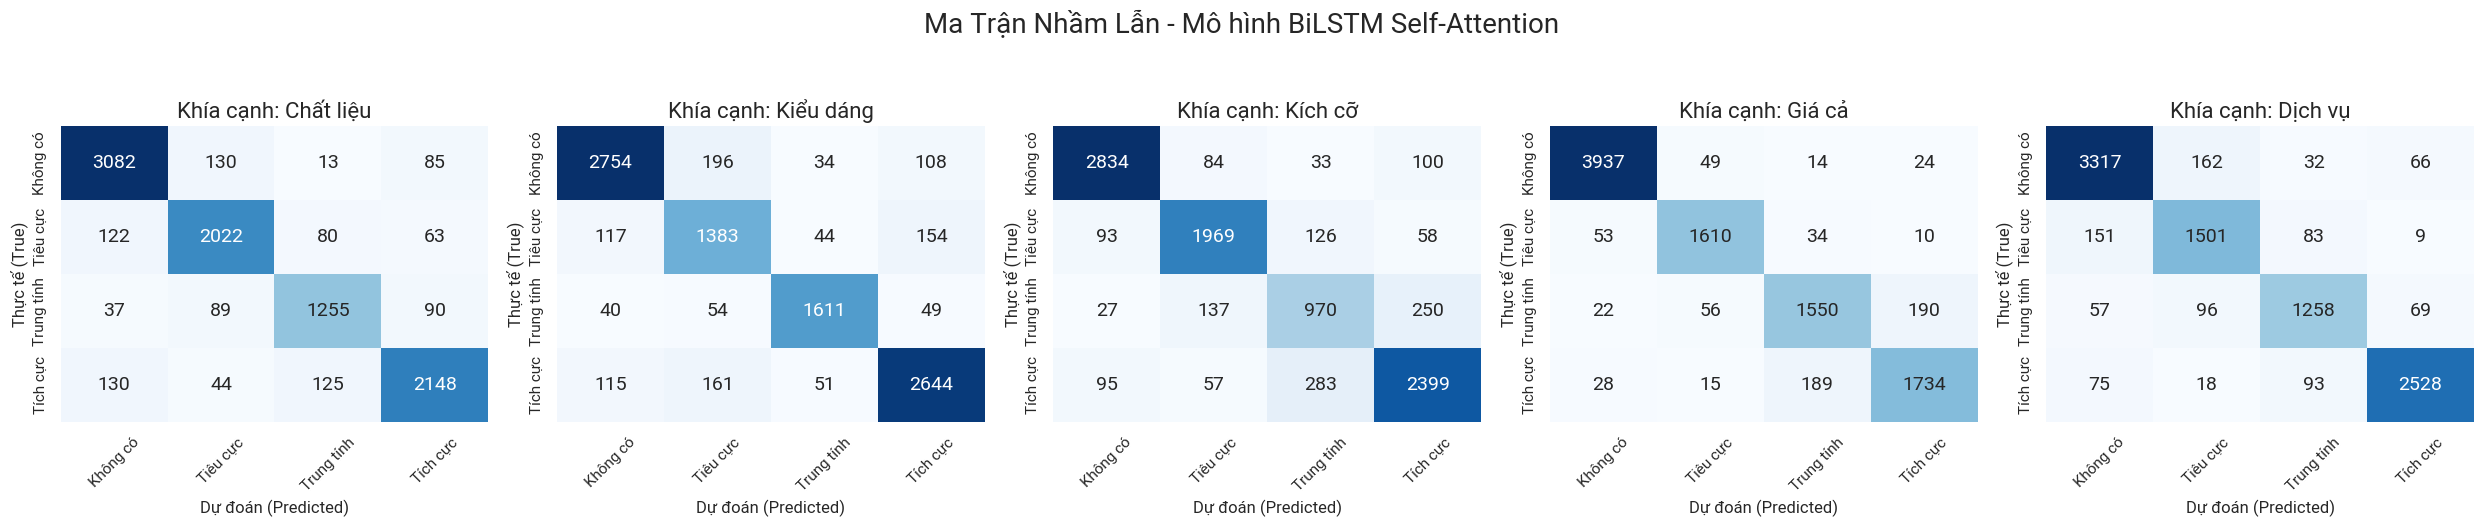

✅ Đã lưu hình ảnh biểu đồ vào file BiLSTM_Self-Attention_Confusion_Matrix.png


In [21]:
# Cài đặt kích thước khung hình
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle('Ma Trận Nhầm Lẫn - Mô hình BiLSTM Self-Attention', fontsize=20, fontweight='bold', y=1.05)

for i, (key, name) in enumerate(zip(aspect_keys, aspect_names)):
    # Tính toán Confusion Matrix
    cm = confusion_matrix(all_labels[key], all_preds[key])
    
    # Vẽ biểu đồ bằng Seaborn Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], 
                xticklabels=target_names, yticklabels=target_names,
                cbar=False, annot_kws={"size": 14})
    
    axes[i].set_title(f'Khía cạnh: {name}', fontsize=16)
    axes[i].set_xlabel('Dự đoán (Predicted)', fontsize=12)
    axes[i].set_ylabel('Thực tế (True)', fontsize=12)
    
    # Xoay nhãn trục x để dễ đọc hơn
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Lưu lại hình ảnh này để dán vào Word/Báo cáo
fig.savefig("/kaggle/working/BiLSTM_Self-Attention_Confusion_Matrix.png", dpi=300, bbox_inches='tight')
print("✅ Đã lưu hình ảnh biểu đồ vào file BiLSTM_Self-Attention_Confusion_Matrix.png")